In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

import os
os.environ["OMP_NUM_THREADS"] = "1"
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


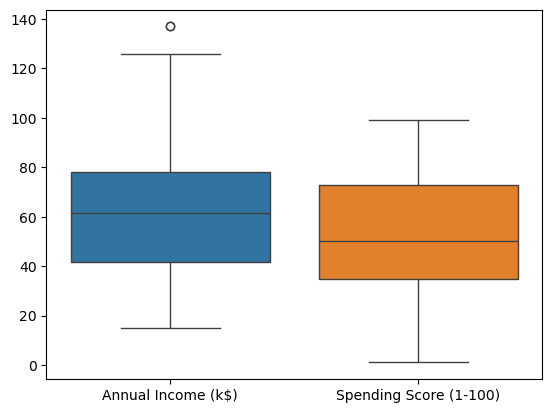

In [3]:
df.info()
df.describe()
sns.boxplot(data=df[['Annual Income (k$)','Spending Score (1-100)']])

df.dropna(inplace=True)

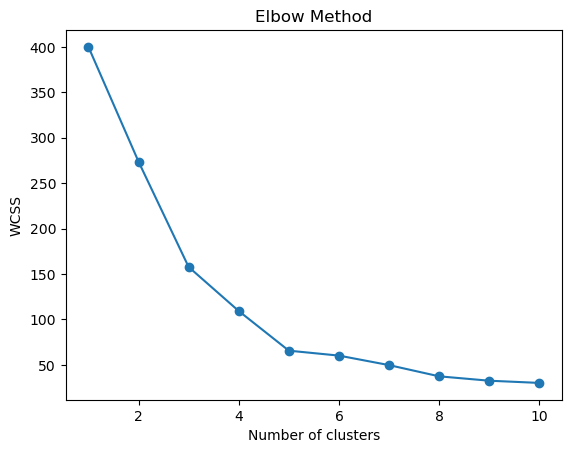

In [4]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


wcss = []
for i in range(1,11):
 kmeans = KMeans(n_clusters=i, random_state=42)
 kmeans.fit(X_scaled)
 wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")
plt.show()

2 0.3949494377743765
3 0.46658474419000145
4 0.49434988482196784
5 0.5546571631111091
6 0.4779883190049936


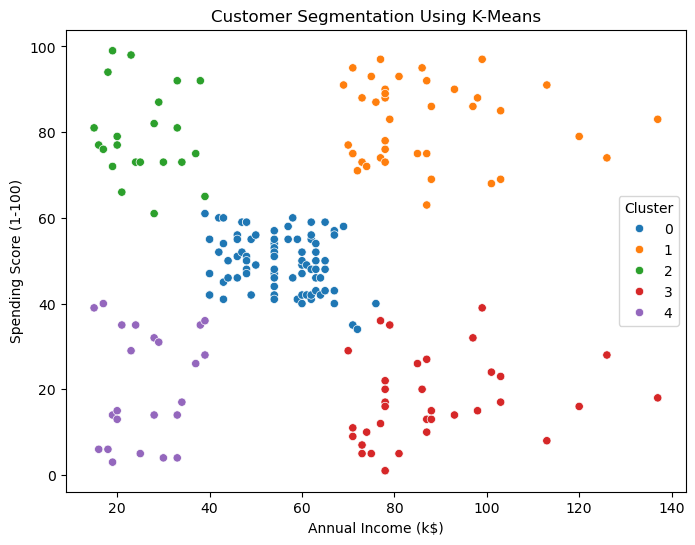

In [5]:
for k in range(2,7):
 kmeans = KMeans(n_clusters=k).fit(X_scaled)
 print(k, silhouette_score(X_scaled, kmeans.labels_))

kmeans = KMeans(n_clusters=5, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)


plt.figure(figsize=(8,6))
sns.scatterplot(
 x=df['Annual Income (k$)'],
 y=df['Spending Score (1-100)'],
 hue=df['Cluster'],
 palette='tab10'
    )
plt.title("Customer Segmentation Using K-Means")
plt.show()



cluster_summary = df.groupby('Cluster').agg({
 'Annual Income (k$)': 'mean',
 'Spending Score (1-100)': 'mean',
 'CustomerID': 'count'
}).rename(columns={'CustomerID':'Cluster Size'})